# Movie Ratings Analysis

## Introduction
This project analyzes factors affecting movie ratings.

## Data Sources

- https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata
- https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset

In [1]:
import pandas as pd

movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [2]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [3]:
movies['vote_average'].mean()

np.float64(6.092171559442016)

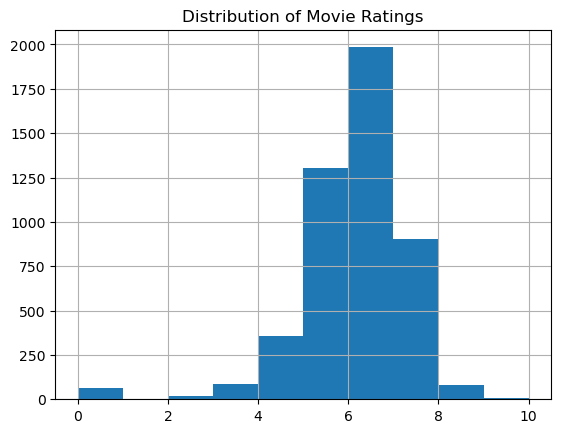

In [4]:
import matplotlib.pyplot as plt

movies['vote_average'].hist()
plt.title("Distribution of Movie Ratings")
plt.show()

## Rating Distribution

The histogram shows how movie ratings are distributed. Most movies have ratings between 5 and 7.

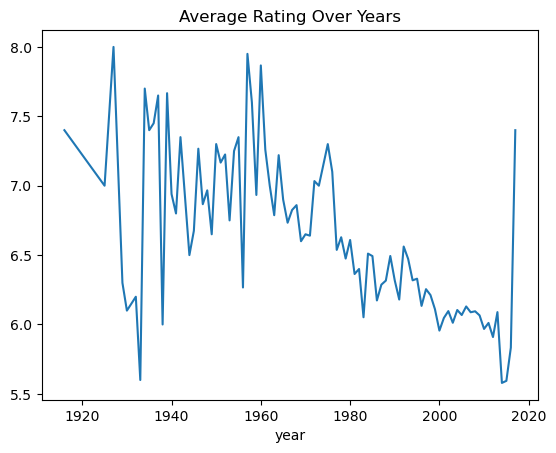

In [5]:
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

movies['year'] = movies['release_date'].dt.year

movies.groupby('year')['vote_average'].mean().plot()
plt.title("Average Rating Over Years")
plt.show()

## Ratings Over Time

This graph shows how average movie ratings have changed over the years.

In [6]:
top_movies = movies.sort_values(by='vote_average', ascending=False)

top_movies[['title', 'vote_average']].head(10)

,title,vote_average
3519,Stiff Upper Lips,10.0
4247,Me You and Five Bucks,10.0
4045,"Dancer, Texas Pop. 81",10.0
4662,Little Big Top,10.0
3992,Sardaarji,9.5
2386,One Man's Hero,9.3
2970,There Goes My Baby,8.5
1881,The Shawshank Redemption,8.5
2796,The Prisoner of Zenda,8.4
3337,The Godfather,8.4


## Top Rated Movies

This table shows the top 10 highest-rated movies in the dataset.

In [8]:
top_movies = movies.sort_values(by='vote_average', ascending=False)
top_10 = top_movies[['title', 'vote_average']].head(10)

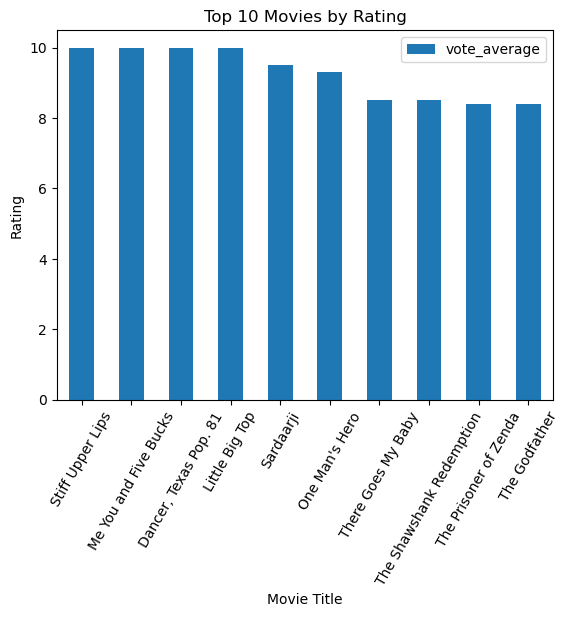

In [9]:
import matplotlib.pyplot as plt

top_10.plot(x='title', y='vote_average', kind='bar')
plt.title("Top 10 Movies by Rating")
plt.xlabel("Movie Title")
plt.ylabel("Rating")
plt.xticks(rotation=60)
plt.show()

This bar chart highlights the highest-rated movies, making it easier to compare their ratings visually.